# Define some functions

In [211]:
import os, sys
import glob
import tifffile as tiff
import cv2
import pandas as pd
import numpy as np
from sklearn import preprocessing
import matplotlib.pyplot as plt
#from caiman.source_extraction import cnmf

import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from scipy.signal import chirp, find_peaks, peak_widths

from scipy import signal



In [212]:
def process_frame(df):
    
    '''
    Aim:
        frame 0 at trace file may not sart from time 0
        called in function `add_event_label()`
    '''
    
    # get frame list
    frame_list = df.index.values.tolist()
    
    # get starting value
    a = frame_list[0]
    new_frame_list = [(i-a) for i in frame_list]
    
    return(new_frame_list)



# process event_label list
# event+label starts from 10, but trace start from 0, deduct 10 from event_start&end time
#----------------------------------------------------------------------------------

def process_event_interval(df):
    
    '''
    Aim:
        time in event file doesn't always start from 0s, fix that
        called in function `add_event_label()`
    '''
    
    new_col = []
    for col in df.columns.tolist():
        new_col.append(col.strip())
    df.columns = new_col
    
    event_list = df[['From Second','To Second']].values.tolist()
    startTime = df['From Second'].values.tolist()[0]
    new_event_list = []
    for event in event_list:
        new_event = [x -startTime for x in event]
        new_event_list.append(new_event)
    return(new_event_list)



    
# get enevt label for an event file based on different mice and session
# for each session, we have separate event file
#----------------------------------------------------------------------------------


def get_event_label(event_df):
    
    '''
    Aim:
        for OFT
        translate 'event' in eventFile to integer label
        each row (corresponding to each time interval) of event is assigned a label
        called in function `add_event_label()`
    '''
    
    # get event status list
    Event_status = event_df['Event'].values.tolist()
    # compact event label list for three sessions
    event_label = []
    

    for i in Event_status:   
        if i.strip() == 'sniff':
            event_label.append(11)
        elif i.strip() == 'sniffed' :
            event_label.append(12)
        elif i.strip() == 'freezing':
            event_label.append(21)
        elif i.strip() == 'cs':
            event_label.append(22)
        elif i.strip() == 'In_all':
            event_label.append(23)
        else:
            event_label.append(24)
                
                
    return(event_label)



# process events file, add event label for string label
#----------------------------------------------------------------------------------

def add_event_label(trace_df, event_path):

    '''
    Aim:
        add event_label to each frame
        one frame can have several label (since mouse can in a location and do something)
    
    Retrun:
        trace dataframe with one label column
    '''
    
    frame_list = process_frame(trace_df)
    #get event dataframe/eventIntervals/eventLabel
#     event_df = pd.read_csv(event_path)
    event_df = pd.read_excel(event_path)
    interval_list = process_event_interval(event_df)
    event_label = get_event_label(event_df)

    
    # add label to each frame
    frame_label_list = []
    for frame in frame_list:
        frame_label = str()
        
        for i in range(len(interval_list)): # one frame can be in several interval
            if min(interval_list[i])  <= frame <= max(interval_list[i]) :
                frame_label = frame_label+ str(event_label[i])

        # convert str to int
        if len(frame_label) == 0:
            frame_label = np.nan
        else:
            frame_label = int(frame_label)

        # append frame label to list
        frame_label_list.append(frame_label)
    
    
    # add label list to trace df 
    new_df = trace_df.copy()
    new_df['Frame_Label']  =  frame_label_list
    new_df = new_df.dropna()
    
    print('The df shape of trace df with label:',new_df.shape)
    
    return(new_df)



In [213]:
def preprocess_image(img):
    """预处理图像：归一化、增强对比度"""  
    ### 在对于longitudal registeration 后export出的image进行分析时，
    ###整个的亮度和对比对都比较低，需要使用该步骤先处理图片。
    # 归一化到0-255
    img_normalized = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    img_uint8 = img_normalized.astype(np.uint8)
    
    # 使用CLAHE增强对比度
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(img_uint8)
    
    return enhanced



# 提取tiff中每个neuron的轮廓
#---------------------------------------------------------------------------
def get_contour(one_neuron_path, thres=160):
                                  ### 可以调整thres值的大小来找出合适的concour轮廓！！！
    '''
    get contour for each neuron through 'C*.tiff'
    '''
    
    # read an image in the currect TIFF directory as a numpy array
    img = tiff.imread(one_neuron_path)
    # 预处理图像
    processed_img = preprocess_image(img)

    print(f"处理神经元: {os.path.basename(one_neuron_path)}")
    #print(f"图像形状: {processed_img.shape}, 最小值: {np.processed_min(img)}, 最大值: {np.processed_max(img)}")

    # set up new file path
    new_file=one_neuron_path[:-5]+'.jpg'

    # save image to a specified file, (filename, img to ve saved)
    cv2.imwrite(new_file, processed_img)

    # re-read the image using cv2
    processed_img = cv2.imread(new_file)

    # convert BGR to Gray scale
    gray = cv2.cvtColor(processed_img, cv2.COLOR_BGR2GRAY)

    # threshold explain
    # find the most shining neuron
    # https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_thresholding/py_thresholding.html
    ret , binary = cv2.threshold (gray , thres , 255 , cv2.THRESH_BINARY)

    # detect contour
    # for better accuracy, use binary image
    # finding contours is like finding white object from black background - gray scale
    # RETR_EXTERNAL - returns only extreme outer flags
    # CHAIN_APPROX_SIMPLE - only save necessary points to represent the line
    # https://docs.opencv.org/trunk/d4/d73/tutorial_py_contours_begin.html
    contours , hierarchy = cv2.findContours(binary , cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # 调试输出
    print(f"找到轮廓数量: {len(contours)}")
    if len(contours) > 0:
        print(f"最大轮廓面积: {max([cv2.contourArea(c) for c in contours])}")
    
    # delete new_file in the folder
    os.remove(new_file)
    
    return(contours)

In [214]:
# get neuron index in all neuron list
#---------------------------------------------------------------------------
def get_index(status_list, root_path_on_off_summary, root_path, mouse_name):
    
    # get on_off summary file
    project = 'social'
    #session_name = 'session_1_ONOFF.csv'  ### define file name, choose which session you want to plot? #############
    #on_off_df = pd.read_csv(os.path.join(root_path_on_off_summary, session_name))
    on_off_df = pd.read_excel(root_path_on_off_summary)
    columns = on_off_df.columns.to_list()
    columns[0] = 'Neurons'
    on_off_df.columns = columns
    on_off_df = on_off_df.set_index('Neurons')

    # 排除索引名为'Frame'的行（如果有的话）
    if 'Frame' in on_off_df.index:
        on_off_df = on_off_df.drop('Frame')

    # get all neuron list 
    trace = os.path.join(root_path, mouse_name, "TRACE_Con.csv")
    trace_df = pd.read_csv(trace, dtype=str) 
    all_neurons = trace_df.columns.tolist()[1:]  # 排除第一列（通常是'Frame'）
    all_neurons = [neuron.strip() for neuron in all_neurons]

    # get status neuron index list
    status_neurons_index_list = []
    for status in status_list:
        status_neurons = on_off_df[on_off_df[status] == 1].index.tolist()
        
        status_neuron_index = []
        for selected_neuron in status_neurons:
            selected_neuron = selected_neuron.strip()
            
            # 确保神经元在all_neurons列表中
            if selected_neuron in all_neurons:
                index = all_neurons.index(selected_neuron)
                status_neuron_index.append(index)
            
            
        status_neurons_index_list.append(status_neuron_index)
    print(status_neurons_index_list)   
    return(status_neurons_index_list)



In [215]:
# get overlap of two lists
#---------------------------------------------------------------------------
def get_overlap(list_1, list_2):
    overlap_list = []
    for i in list_1:
        if i in list_2:
            overlap_list.append(i)
    return(overlap_list)


# Plot neuron contour
- different/same neuron types from two different sessions, labled by different colors
- 它们overlapped neuron以第3种颜色表示

In [216]:
root_path = r'F:/AAA-RXC'       # F:\AAA-Social analysis\Data-Neuron Social\AAA-PL
#root_path_incorrect =  r'D:\zekai_chen\Mini_Scope\Processed data\Social\Incorrect neuron number'
#root_path_on_off_summary = r'CF:\AAA-Social analysis\Data-Neuron Social\AAA-PL'

mice_list = ['PL7-4sessions', ]
#WT_incorrect_neuron_list = ['NC128_WT.txt', 'NC139_WT.txt']
session_name_1 = 'session_1_ONOFF.xlsx' 
session_name_2 = 'session_2_ONOFF.xlsx'
status_list_1 = ['sniff_ON']  ###
status_list_2 = ['freezing_ON']  ###


WT
processing: PL7-4sessions
处理神经元: IMAGE_C000.tiff
找到轮廓数量: 1
最大轮廓面积: 354.0
处理神经元: IMAGE_C001.tiff
找到轮廓数量: 3
最大轮廓面积: 960.5
处理神经元: IMAGE_C002.tiff
找到轮廓数量: 1
最大轮廓面积: 267.0
处理神经元: IMAGE_C003.tiff
找到轮廓数量: 1
最大轮廓面积: 649.0
处理神经元: IMAGE_C004.tiff
找到轮廓数量: 1
最大轮廓面积: 594.0
处理神经元: IMAGE_C005.tiff
找到轮廓数量: 1
最大轮廓面积: 599.0
处理神经元: IMAGE_C006.tiff
找到轮廓数量: 1
最大轮廓面积: 174.0
处理神经元: IMAGE_C007.tiff
找到轮廓数量: 1
最大轮廓面积: 283.0
处理神经元: IMAGE_C008.tiff
找到轮廓数量: 1
最大轮廓面积: 433.0
处理神经元: IMAGE_C009.tiff
找到轮廓数量: 1
最大轮廓面积: 653.5
处理神经元: IMAGE_C010.tiff
找到轮廓数量: 1
最大轮廓面积: 375.0
处理神经元: IMAGE_C011.tiff
找到轮廓数量: 4
最大轮廓面积: 150.5
处理神经元: IMAGE_C012.tiff
找到轮廓数量: 1
最大轮廓面积: 556.5
处理神经元: IMAGE_C013.tiff
找到轮廓数量: 1
最大轮廓面积: 439.0
处理神经元: IMAGE_C014.tiff
找到轮廓数量: 1
最大轮廓面积: 383.0
处理神经元: IMAGE_C015.tiff
找到轮廓数量: 1
最大轮廓面积: 481.5
处理神经元: IMAGE_C016.tiff
找到轮廓数量: 1
最大轮廓面积: 235.5
处理神经元: IMAGE_C017.tiff
找到轮廓数量: 1
最大轮廓面积: 728.5
处理神经元: IMAGE_C018.tiff
找到轮廓数量: 1
最大轮廓面积: 525.5
处理神经元: IMAGE_C019.tiff
找到轮廓数量: 1
最大轮廓面积: 496.5
处理神经元: IMAGE_C020.tiff
找到轮廓数量: 

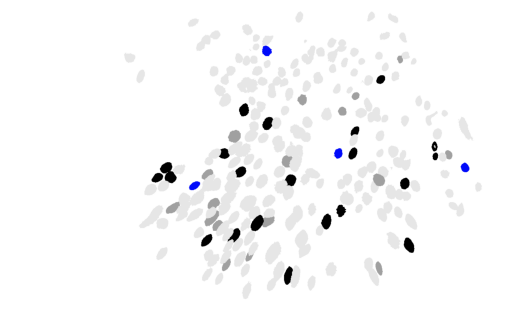

In [217]:
print('WT')

for mouse_name in mice_list:
    print('processing:', mouse_name)
    
    # get folder path for each mouse
    mouse_folder = os.path.join(root_path, mouse_name)
    
    # get all tiff image paths
    target = glob.glob(mouse_folder+os.sep+'IMAGE_C*.tiff')
    
    # get each neuron contour
    contours_all=[]
    for neuron in target:
        contours_all.append(get_contour(neuron))
    
    # get the shpae of tiff img
    rows,cols=tiff.imread(target[0]).shape

    # get neuron_index list
    #status_list = ['sniff_ON', 'freezing_ON']  ###
    root_path_on_off_summary_1 = os.path.join(root_path, 'Results', mouse_name, session_name_1)
    status_neurons_index_list_1 = get_index(status_list = status_list_1, 
                                          root_path_on_off_summary = root_path_on_off_summary_1, 
                                          root_path = root_path, 
                                          mouse_name = mouse_name)
    
    root_path_on_off_summary_2 = os.path.join(root_path, 'Results', mouse_name, session_name_2)
    status_neurons_index_list_2 = get_index(status_list = status_list_2, 
                                          root_path_on_off_summary = root_path_on_off_summary_2, 
                                          root_path = root_path, 
                                          mouse_name = mouse_name)
    
    ON_Neurons_1_index = status_neurons_index_list_1[0]   # sniff_ON
    ON_Neurons_2_index = status_neurons_index_list_2[0]   # freezing_ON
    
    # generate an empty img and fill it white
    img=np.zeros([rows,cols,3],dtype=np.float32)
    img.fill(255)
    
    #调试
    print(f"总神经元数量: {len(contours_all)}")
    print(f"sniff_ON神经元数量: {len(ON_Neurons_1_index)}")
    print(f"freezing_ON神经元数量: {len(ON_Neurons_2_index)}")
    print(f"重叠神经元数量: {len(get_overlap(ON_Neurons_1_index, ON_Neurons_2_index))}")
    
    #draw contour of all neurons and fill with different color based on neuron type
    for i in range(len(contours_all)):
        
        contour = contours_all[i]
        
        if i in get_overlap(ON_Neurons_1_index, ON_Neurons_2_index):
            color =  (0, 10, 250)   # blue (25, 180, 74)# green (250, 250, 50)# yellow - overlap
        elif i in ON_Neurons_1_index:
            color = (0, 0, 0)       # black - center
        elif i in ON_Neurons_2_index:
            color = (160, 160, 160) # dard grey - corner
        else:
            color = (230, 230, 230) # light grey - all
        img=cv2.drawContours(img, contour, -1, color, -1) 
        # change contour color
        # https://stackoverflow.com/questions/51560541/how-to-change-contour-colour-on-opencv-python
    
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.gca().axes.get_yaxis().set_visible(False)
    plt.imshow(img.astype('uint8'))

    save_path = os.path.join(root_path, 'Results', mouse_name + '-sf-1-2.png')
    plt.imsave(save_path, img.astype('uint8'))